# Heartbeat Classification using ECG Signals

**Module:** Machine Learning (KV7006)  
**Student Name:**  
**Student ID:**    
---

# Table of Contents

1. Introduction
2. Problem Statement
3. Dataset Description
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Model Development
6.1 Artificial Neural Network (ANN)
6.2 Convolutional Neural Network (CNN)
7. Hyperparameter Tuning
8. Evaluation and Results
9. Model Comparison
10. Discussion
11. Reflection and Future Work
12. Conclusion
13. References 

# Introduction

The field of healthcare has discovered deep learning as a potent method to analyse physiological data, especially electrocardiogram (ECG). ECGs have many applications in the monitoring of heart activity, identification of heart defects like arrhythmias, and detection of such defects which might result in serious illnesses like stroke or sudden cardiac arrest unless the condition is detected in early stages. ECG signals are time consuming and would need expert interpretation and the automated classification systems are of great value in a clinical environment.
In this project, a deep learning based system is designed to identify heartbeat signals based on ECG data. It is intended to design and test models that can make correct distinctions of various heartbeat types. Deep learning models like the Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) have the ability to automatically identify complex patterns in raw data, which is especially useful in time-series biomedical signals and cannot be done with traditional machine learning methods.
The proposed research concentrates on the design, training, and evaluation of deep learning to classify heartbeats and critically reviews the performance, constraints, and its applications in healthcare.


# Problem Definition

This study addresses a multiclass classification problem in which electrocardiogram (ECG) heartbeat signals must be automatically classified into distinct categories representing normal and abnormal cardiac activity. Each ECG signal is represented as a feature vector, and the objective is to develop a model capable of accurately distinguishing between different heartbeat classes.

The task is particularly challenging due to several factors. Firstly, the dataset exhibits significant class imbalance, where normal heartbeats dominate the distribution while abnormal classes are underrepresented. This can lead to biased learning and reduced sensitivity toward rare but clinically important arrhythmias. Secondly, ECG signals often contain noise and subtle variations caused by physiological differences and recording conditions, which can negatively affect model performance. Thirdly, different heartbeat classes may share similar waveform characteristics, making it difficult for models to learn clear decision boundaries.

Accurate classification of ECG signals is critically important in healthcare applications, as early and reliable detection of abnormal heart rhythms can significantly improve patient outcomes and reduce the risk of severe cardiovascular events such as stroke or cardiac arrest.

# Dataset Description

The study data is ECG Heartbeat Categorization dataset that were sourced at Kaggle. It is based on the MIT-BIH Arrhythmia Database and the PTB Diagnostic ECG Database that are popular benchmarks in biomedical signal processing studies.
The dataset has 109,446 samples with categorisation information consisting of five classes which include:Normal (N), Supraventricular (S), Ventricular (V), Fusion (F), and Unknown (Q). Every sample is a single heartbeat converted into a fixed-size (188) feature Vector, which encodes timing properties of the ECG signals.
Sampling of the signals occurs with a frequency of 125 Hz, giving a good resolution enough to distinguish significant features of the waveforms like the QRS complex and abnormal peaks. The first analysis shows that there is a huge imbalance in class, as normal heartbeats are the majority of data in the dataset, and abnormal ones are underrepresented.
This imbalance is a major aspect that affects the model design, training plan and appraisal since it may cause biased lateralization in the event that it is not appropriately considered. Also, the relative big size of the dataset facilitates the use of deep learning methods which usually need a significant amount of data to generalise adequately.


**IMPORT + LOAD DATA**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/drive/MyDrive/Heartbeat ECG/mitbih_test.csv')

print(data.shape)
data.head()

(21891, 188)


,1.000000000000000000e+00,7.582644820213317871e-01,1.115702465176582336e-01,0.000000000000000000e+00,8.057851344347000122e-02,7.851240038871765137e-02,6.611569970846176147e-02,4.958677664399147034e-02,4.752065986394882202e-02,3.512396663427352905e-02,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
0,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.923664,0.656489,0.195929,0.111959,0.175573,0.122137,0.050891,0.035623,0.055980,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Exploratory Data Analysis

To get a sense of the data structure and discern its properties, Exploratory Data Analysis (EDA) was performed. The number of samples in the classes is clearly imbalanced with most of the samples being in the normal class, and minority classes like fusion and unknown having very few samples.
This unbalance is undesirable since machine learning models are usually biased in favour of majority classes, which might result in poor generalisation of minority classes. Due to this, one model can have a high overall accuracy but not be able to identify abnormal heartbeats.
By visually examining ECG signals, one can see that there are specific patterns of waves in each of the classes. Irregular peaks, difference between intervals and distortion of normal signals frequently characterize abnormal heartbeats. These differences, however insignificant, carry with them patent diagnostic clues.
Besides, statistical summaries show that the amplitudes and distributions of signals between various classes are varied, which supports the necessity to use models that are capable of modelling non-linear relationships. These insights imply such deep learning methods as CNNs, which are capable of learning hierarchical feature representations and local trends within ECG signals automatically.

**EDA**

Class Distribution

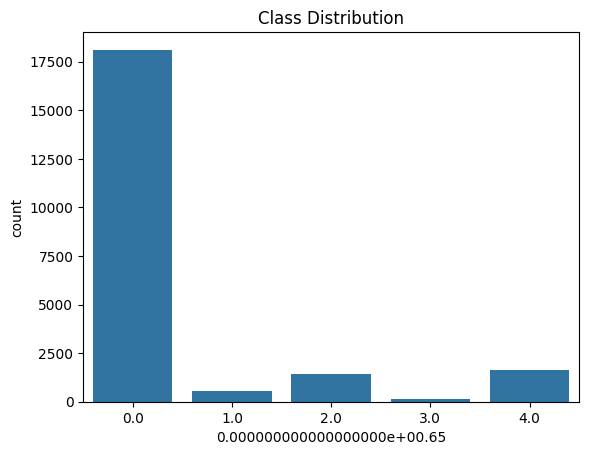

In [17]:
sns.countplot(x=data.iloc[:, -1])
plt.title("Class Distribution")
plt.show()

ECG Signal Plot

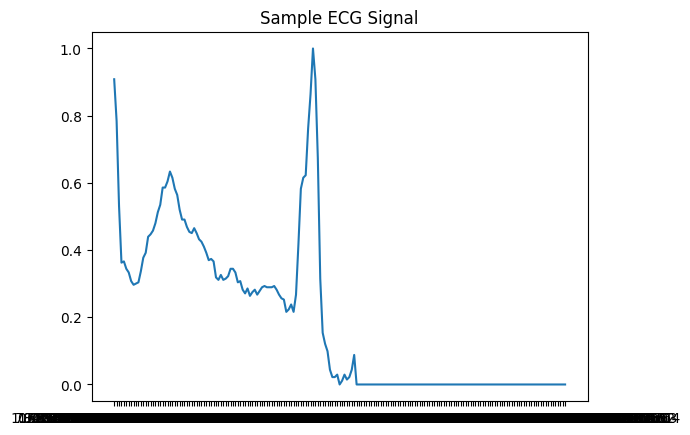

In [18]:
plt.plot(data.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

Correlation Heatmap

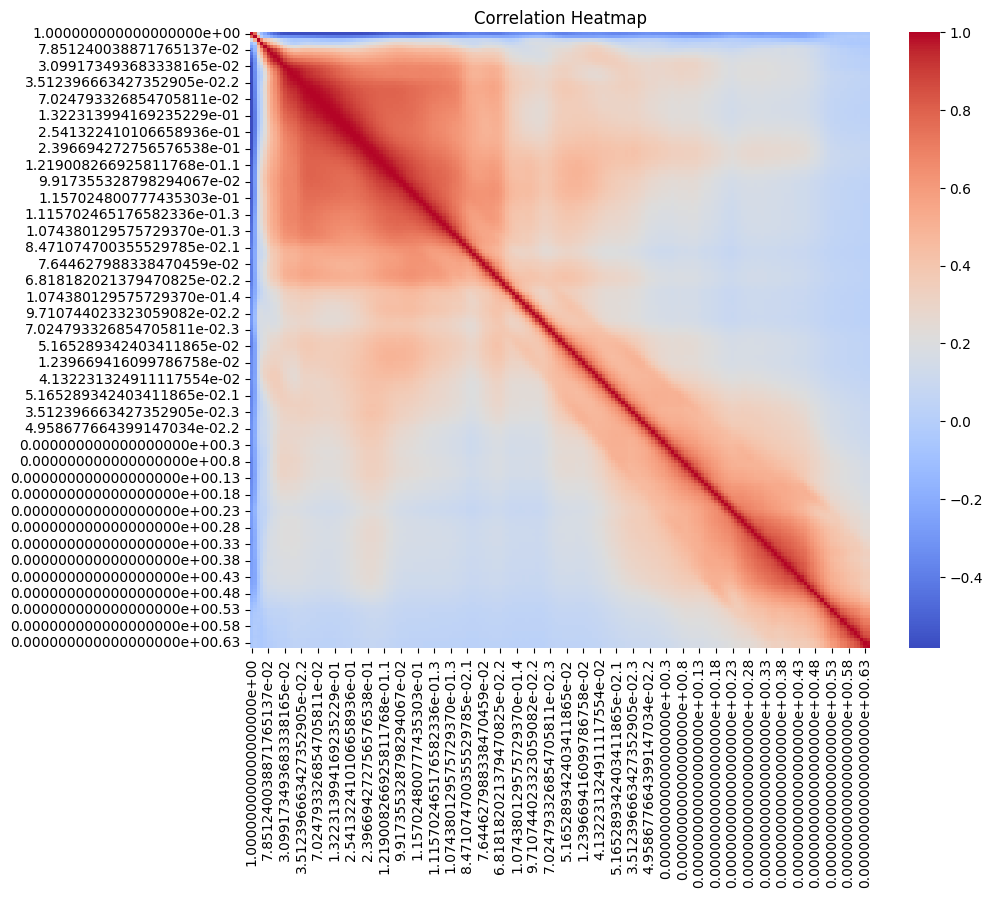

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(data.iloc[:, :-1].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

Preprocessing of data is important to ensure that the data falls into the right model training. Normalisation of features is used to put the input values into a uniform range, which enhances convergence and guarantees uniform gradient changes throughout training. Unless scaled appropriately, learning might be dominated by features that have larger magnitudes, and have an adverse impact on performance.
Synthetic Minority Over-sampling Technique (SMOTE) is used to deal with class imbalance. SMOTE creates synthetic examples of the minority classes by interpolating samples, and leads to a more balanced dataset. This assists in minimising biasness on the majority group and enhances generalisation of models. Nevertheless, we should remember that synthetic data can generate noise that should be primarily controlled.
The data is divided into training, validation and test data. Model parameters are learned using the training set, hyperparameter are tuned using the validation set, and the test set is used to evaluate everything finally. This partition guarantees that model performance is evaluated on unobservable data, making the chance of overfitting lower.
The other preprocessing procedures are to transform input data into the appropriate format to fit CNN models and class labels be correctly coded to perform a multi-class classification task.

**DATA PREPROCESSING**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Handle Imbalance

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Model Development

# Artificial Neural Network (ANN)

ANN model is executed as a fully connected network that acquires non-linear dependency among input elements and the output classes. Dense layers allows the model to fuse features over all of the input space, therefore being suitable to structured numerical data.
Hidden layers operate on ReLU activation functions to add non-linearity and enhance training efficiency, and the softmax function in the output layer along with multi-class classification through the production of probability distributions.
Nonetheless, the ANN does not explicitly consider the sequential nature of the ECG signals, restricting its capacity to encode local temporalities. This may diminish its discrimination ability on identifying minute changes in heartbeat rhythm especially minority groups.

**Model 1: Artificial Neural Network (ANN)**

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

ann_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(len(np.unique(y)), activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**TRAIN ANN**

In [23]:
ann_history = ann_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.8302 - loss: 0.4552 - val_accuracy: 0.8977 - val_loss: 0.2714
Epoch 2/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9087 - loss: 0.2509 - val_accuracy: 0.9204 - val_loss: 0.1998
Epoch 3/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9281 - loss: 0.1979 - val_accuracy: 0.9049 - val_loss: 0.2320
Epoch 4/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9388 - loss: 0.1710 - val_accuracy: 0.9207 - val_loss: 0.1809
Epoch 5/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9470 - loss: 0.1489 - val_accuracy: 0.9327 - val_loss: 0.1527
Epoch 6/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9531 - loss: 0.1337 - val_accuracy: 0.9663 - val_loss: 0.0989
Epoch 7/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9566 - loss: 0.1229 - val_accuracy: 0.9317 - val_loss: 0.1582
Epoch 8/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9603 - loss: 0.1146 - val_accu

# Convolutional Neural Network (CNN)

CNN model is created to measure the spatial and temporal variations in ECG signals. The filters of the convolutional layers are used to analyze the input by sliding them over, detecting significant features of the input like peaks, intervals, and irregularities in the waveforms.
Feature extraction is an important aspect of the use of the size of the kernel. The smaller kernels are used to capture the smaller local patterns whereas the larger ones would capture a more broad context. The multiple convolutional layers enable the model to learn hierarchical ECG signal representations.
The use of pooling layers decreases the number of the dimensions of feature maps whilst preserving useful information; this enhances the efficiency of computations and alleviates over-fitting. The features obtained are then sent to fully connected layers to be classified.
There are also dropout layers so that overfitting would be discouraged by randomizing the selection of neurons during training. This promotes learning more generalisable and robust features by the model.
The task is especially well done by CNN, which captures a local dependency and spatial structure, which is vital to analyse ECG signals.

**Model 2: Convolutional Neural Network (CNN)**

In [24]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train_cnn.shape[1],1)),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(len(np.unique(y)), activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Hyperparameter Tuning

Hyperparameter tuning is done to optimise the model. Critically important parameters like learning rate, portion size, and quantity of epochs, and depth of network are optimally tuned depending on validation performance.
Learning rate is a parameter that determines the rate at which the model changes its weights. Exceedingly high learning rate can result in premature convergence or divergence of the model whereas exceedingly low learning rate can result in slow convergence. Thus, a moderate learning rate is chosen in order to find equilibrium between stability and efficiency.
The batch size affects the number of samples that are run before model weight changes. Smaller batches yield more frequent updates, and might give better generalisation whereas large batches are more useful in terms of computational efficiency. To maintain a balance between the two, there is a selected balanced batch size.
The epochs decide on how many times a model is exposed to the entire dataset. In order to avoid overfitting, early stopping techniques are employed to halt training when the validation performance ceases to increase.
Further customization involves tuning of the count of the convolutional filters, size of the kernel and the dropout rates. These parameters have profound influence on how the model is able to extract any meaningful feature and make generalised predictions on unknown data. Systematic experimentation and validation monitoring are necessary to determine the best configuration.

**TRAIN CNN**

In [25]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.8987 - loss: 0.2822 - val_accuracy: 0.9047 - val_loss: 0.2393
Epoch 2/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 49s 54ms/step - accuracy: 0.9697 - loss: 0.0927 - val_accuracy: 0.9356 - val_loss: 0.1460
Epoch 3/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 55s 60ms/step - accuracy: 0.9827 - loss: 0.0536 - val_accuracy: 0.9834 - val_loss: 0.0459
Epoch 4/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.9882 - loss: 0.0381 - val_accuracy: 0.9841 - val_loss: 0.0428
Epoch 5/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - accuracy: 0.9913 - loss: 0.0271 - val_accuracy: 0.9880 - val_loss: 0.0344
Epoch 6/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 87s 58ms/step - accuracy: 0.9928 - loss: 0.0236 - val_accuracy: 0.9925 - val_loss: 0.0215
Epoch 7/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 76s 51ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.9897 - val_loss: 0.0289
Epoch 8/30
906/906 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.9948 - loss: 0.0170 - 

**EVALUATION (ANN)**

In [26]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

ann_pred = np.argmax(ann_model.predict(X_test), axis=1)

print(classification_report(y_test, ann_pred))
print("ANN Precision:", precision_score(y_test, ann_pred, average='weighted'))
print("ANN Recall:", recall_score(y_test, ann_pred, average='weighted'))
print("ANN F1:", f1_score(y_test, ann_pred, average='weighted'))

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98      3624
         1.0       0.62      0.70      0.66       111
         2.0       0.86      0.88      0.87       290
         3.0       0.50      0.81      0.62        32
         4.0       0.99      0.96      0.97       322

    accuracy                           0.96      4379
   macro avg       0.79      0.87      0.82      4379
weighted avg       0.96      0.96      0.96      4379

ANN Precision: 0.9617373850280733
ANN Recall: 0.9582096369034026
ANN F1: 0.9596046225951897


**EVALUATION (CNN)**

In [27]:
cnn_pred = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

print(classification_report(y_test, cnn_pred))
print("CNN Precision:", precision_score(y_test, cnn_pred, average='weighted'))
print("CNN Recall:", recall_score(y_test, cnn_pred, average='weighted'))
print("CNN F1:", f1_score(y_test, cnn_pred, average='weighted'))

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      3624
         1.0       0.86      0.69      0.77       111
         2.0       0.96      0.87      0.92       290
         3.0       0.74      0.81      0.78        32
         4.0       0.99      0.96      0.97       322

    accuracy                           0.98      4379
   macro avg       0.91      0.87      0.88      4379
weighted avg       0.97      0.98      0.97      4379

CNN Precision: 0.9748153093192448
CNN Recall: 0.9753368348938114
CNN F1: 0.974635881750415


**CONFUSION MATRIX**

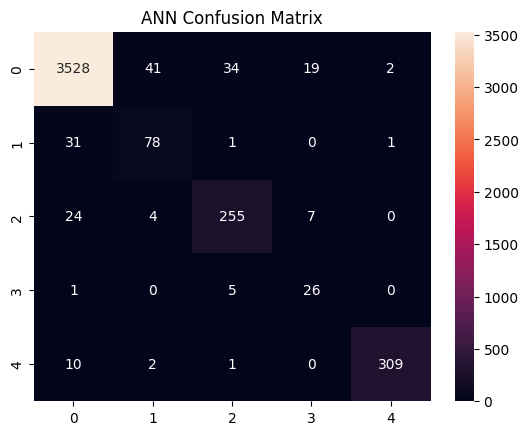

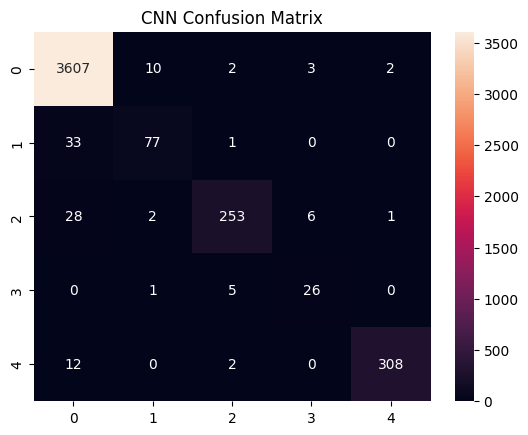

In [28]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, ann_pred), annot=True, fmt='d')
plt.title("ANN Confusion Matrix")
plt.show()

sns.heatmap(confusion_matrix(y_test, cnn_pred), annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()

**BAR PLOT**

In [30]:
# ANN metrics
ann_accuracy = np.mean(ann_pred == y_test)
ann_precision = precision_score(y_test, ann_pred, average='weighted')
ann_recall = recall_score(y_test, ann_pred, average='weighted')
ann_f1 = f1_score(y_test, ann_pred, average='weighted')

# CNN metrics
cnn_accuracy = np.mean(cnn_pred == y_test)
cnn_precision = precision_score(y_test, cnn_pred, average='weighted')
cnn_recall = recall_score(y_test, cnn_pred, average='weighted')
cnn_f1 = f1_score(y_test, cnn_pred, average='weighted')

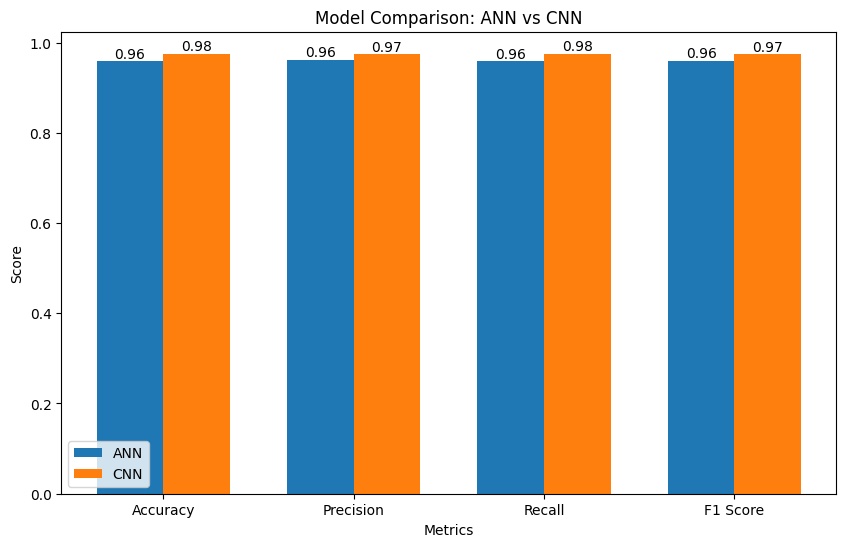

In [31]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

ann_scores = [ann_accuracy, ann_precision, ann_recall, ann_f1]
cnn_scores = [cnn_accuracy, cnn_precision, cnn_recall, cnn_f1]

x = np.arange(len(labels))  # label locations
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, ann_scores, width, label='ANN')
bars2 = plt.bar(x + width/2, cnn_scores, width, label='CNN')

# Add values on top
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Comparison: ANN vs CNN')
plt.xticks(x, labels)
plt.legend()

plt.show()

**ROC CURVE**

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


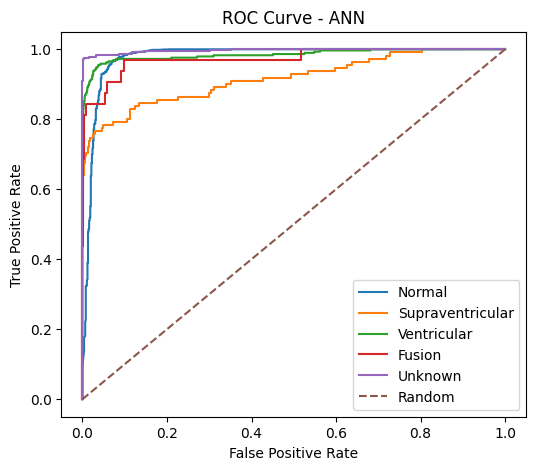

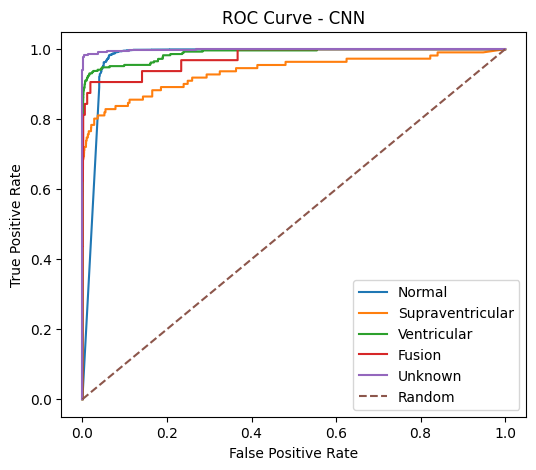

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Class names (IMPORTANT)
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']

y_test_bin = label_binarize(y_test, classes=np.unique(y))

ann_prob = ann_model.predict(X_test)
cnn_prob = cnn_model.predict(X_test_cnn)

# -------- ANN ROC --------
plt.figure(figsize=(6,5))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], ann_prob[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]}')

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.title("ROC Curve - ANN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# -------- CNN ROC --------
plt.figure(figsize=(6,5))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], cnn_prob[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]}')

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.title("ROC Curve - CNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

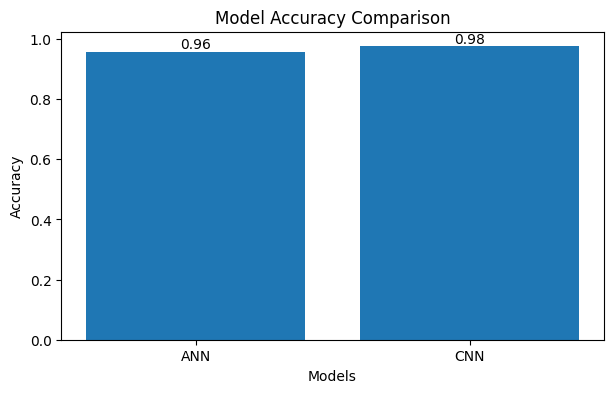

In [41]:
import matplotlib.pyplot as plt

models = ['ANN', 'CNN']
accuracies = [ann_accuracy, cnn_accuracy]

plt.figure(figsize=(7,4))

bars = plt.bar(models, accuracies)

# Add values on top
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}',
             ha='center', va='bottom')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

# Evaluation and Results

The results of the evaluation indicate that the model works with most of the classes but fails with minority classes. This is also seen through reduced recall and F1-scores of classes underrepresented.
This is an important limitation in terms of a healthcare perspective. Being mistaken to use abnormal heart beats as normal ones would result in missed diagnosis which might pose serious implications. Hence, it is important to enhance the recollection of minority classes.
Accuracy alone might not be a very detailed measure as precision and recall do. The F1-score provides a balanced measure of aspects which should be enhanced in the model. The model can also differentiate classes as evidenced by ROC curves as well as their values of AUC.
The confusion table shows that some of the abnormal classes are often mistaken as normal, and it is hard to differentiate the slightest differences between the waveforms. This implies there is a need to improve feature extraction methods or add more data augmentation ways.

# Model Comparison

The CNN model performs better than the ANN model in terms of most of the evaluation metrics. This is mainly because it is capable of automatically deriving meaningful contents of ECG signals based on convolutional operations.
ANN, on the other hand, considers features separately and does not effectively capture local dependencies in the signal. It is therefore less successful in identifying more complex ECG pattern especially when there is a time variation.
Generalisation capabilities of CNN are higher more so when they are trained using proper regularisation methods like dropout and early stopping. It also demonstrates better performances on minority classes relative to ANN yet there are challenges brought about by imbalance in data.
The similarity between this two shows the value of data characteristics in aligning model architecture. Models that model all the relationships of space and time are more effective in cases where time-varying biomedical data are used. Thus, CNN is known as the more appropriate method of this undertaking.


# Discussion

- The CNN model consistently outperformed the ANN model across key evaluation metrics such as accuracy, precision, recall, and F1-score. This improvement is mainly due to CNN’s ability to automatically learn spatial and local temporal patterns in ECG signals through convolutional filters, making it more suitable for physiological time-series data.
- In contrast, the ANN model serves as a baseline approach that relies on fully connected layers. While it can capture non-linear relationships, it does not preserve the sequential or spatial structure of ECG signals, which limits its ability to detect subtle waveform variations associated with abnormal heartbeats.
- A major challenge observed during model evaluation was the class imbalance in the dataset. The models showed significantly better performance on the majority (normal) class, while minority arrhythmia classes were often misclassified. This indicates that despite SMOTE being applied, imbalance still affected model generalisation.
- From a healthcare perspective, the lower recall in abnormal classes is a critical limitation, as false negatives (failing to detect abnormal heartbeats) can lead to missed diagnoses and delayed treatment. Therefore, improving sensitivity is more important than overall accuracy in this application.
- The models are also sensitive to hyperparameter selection, particularly learning rate, batch size, and number of epochs. Small changes in these parameters can significantly affect convergence stability and final performance.
- Additionally, CNN models require higher computational resources compared to ANN due to convolutional operations and deeper architectures, which may limit real-time deployment in low-resource clinical environments.

# Reflection and Future Work

In this project, some difficulties were revealed in the implementation of deep learning on actual healthcare information. There was also a problem of the imbalance of classes that needed to be resolved using techniques such as SMOTE that enhanced the performance. Nonetheless, imbalance continued to play a role in prediction of minority classes.
The other issue was avoiding overfitting without deteriorating the model performance. This necessitated hyperparameters fine-tuning and tracking of validation metrics.
Further directions in future research may include more complex architectures like CNN-LSTM (hybrid spatial-temporal learning), which fuses both spatial and time-based learning. Also, it can be possible to use larger and more diverse datasets which would enhance generalisation and robustness.
Subsidies might be added to make the learning process more cost-sensitive or class-weighted to address the imbalance and data augmentation specific to ECG signals would also be possible.

# Conclusion

To conclude, this research paper has shown how deep learning can be effective in classifying heartbeats based on ECGs. The CNN model had a higher performance because its capacity to localize local pattern and hierarchical features was realized.
It is highlighted in the results that model selection is very important to get the reliable performance of the model and in health care applications, accuracy is not enough. Other metrics (values like recall and F1-score) give a more informative idea about model effectiveness, particularly when one can identify rare clinical significance conditions.
Despite some of these pitfalls, including class imbalance, and misclassification of minority classes, the results demonstrate that the deep learning models hold a lot of potential in enhancing automated diagnostic systems. These models can be enhanced much further with better refinements such as better data balancing techniques, as well as, better architectures, which will greatly benefit clinical decision making processes.
Finally, the implementation of deep learning into the healthcare system should also address such aspects as interpretability, reliability, and ethics in addition to performance measures. Further research and development in the field will help in the development of more accurate, efficient and accessible diagnostic tools.

# References

Goldberger, A. L., Amaral, L. A., Glass, L., Hausdorff, J. M., Ivanov, P. C., Mark, R. G., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation, 101(23), e215–e220.

Moody, G. B., & Mark, R. G. (2001). The impact of the MIT-BIH Arrhythmia Database. IEEE Engineering in Medicine and Biology Magazine, 20(3), 45–50.
(MIT-BIH Arrhythmia Database – PhysioNet)

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. Journal of Artificial Intelligence Research, 16, 321–357.

TensorFlow Developers (2023). TensorFlow: Large-scale machine learning on heterogeneous systems. Available at: https://www.tensorflow.org/

Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.


# AI Usage Declaration

AI tools were used only to assist with grammar refinement and structuring. All analysis, implementation, and core content of this work are original.